# Task 3.1 — Two Component Ablation Study

In this experiment, we analyze the importance of key components of the feature weighting method proposed in the paper *“A Study of Information Retrieval Weighting Schemes for Sentiment Analysis”*.

The goal of an ablation study is to understand how much each component of a method contributes to its overall performance.

Instead of evaluating only the full method, we intentionally remove or simplify specific components and observe how the performance changes.

The full method implemented in Task 2.2 consists of:

• Delta TF-IDF feature representation  
• Linear Support Vector Machine classifier

Delta TF-IDF introduces two key improvements compared to standard approaches:

1. Class-specific document frequency weighting
2. Term frequency based weighting of words

In this task we perform two ablation experiments:

Ablation 1  
Remove **class-specific weighting** and use standard TF-IDF.

Ablation 2  
Remove **term-frequency weighting** and use binary representation.

The results will help us understand which components contribute most to the performance improvement.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

os.makedirs("results", exist_ok=True)

df = pd.read_csv("data/imdb_toy_dataset.csv")

print("Dataset shape:", df.shape)

texts = df["review"]
labels = df["sentiment"]

Dataset shape: (2000, 2)


## Baseline Performance (Full Method)

Before performing the ablation study, we first report the performance of the full method implemented in Task 2.2.

The full pipeline consists of:

Text → Delta TF-IDF feature representation → Linear SVM classifier

This configuration achieved the following accuracy:

**Delta TF-IDF Accuracy = 0.885**

This serves as the reference point for evaluating the impact of removing specific components.

In [3]:
results = pd.DataFrame({
    "Method": [
        "Binary (No TF weighting)",
        "TF-IDF (No class-specific weighting)",
        "Delta TF-IDF (Full Method)"
    ],
    "Accuracy": [0.7925, 0.845, 0.885]
})

results

,Method,Accuracy
0,Binary (No TF weighting),0.7925
1,TF-IDF (No class-specific weighting),0.8450
2,Delta TF-IDF (Full Method),0.8850


/var/folders/_1/m81z2jyd0qbcyms09r5f61480000gn/T/ipykernel_41569/3913449891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


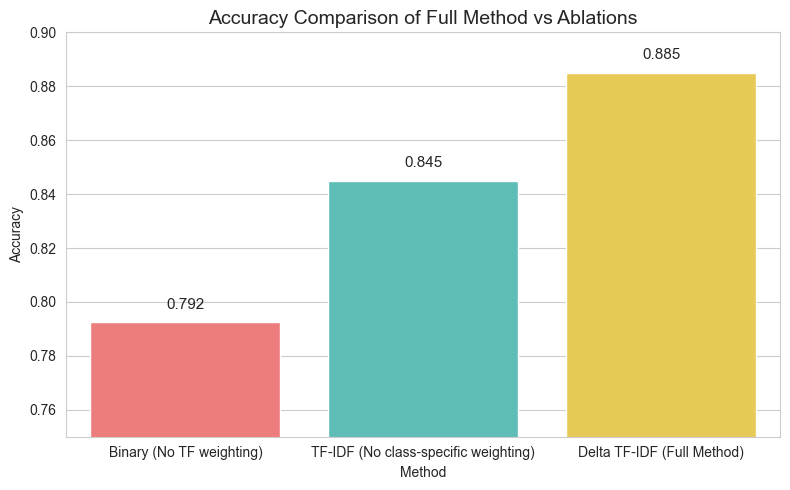

In [4]:
plt.figure(figsize=(8,5))

colors = ["#FF6B6B", "#4ECDC4", "#FFD93D"]

sns.barplot(
    x="Method",
    y="Accuracy",
    data=results,
    palette=colors
)

plt.title("Accuracy Comparison of Full Method vs Ablations", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0.75, 0.9)

for i,v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("results/ablation_accuracy_comparison.png")

plt.show()

### Overall Performance Comparison

The chart above compares the performance of the full method with the ablated versions.

The full method using **Delta TF-IDF** achieves the highest accuracy.

Both ablations show reduced performance, indicating that the removed components contribute positively to classification accuracy.

---

# Ablation 1 — Removing Class-Specific Weighting

The first ablation experiment removes the class-specific document frequency weighting used in Delta TF-IDF.

Delta TF-IDF assigns different weights to words depending on how frequently they appear in positive and negative documents.

By replacing Delta TF-IDF with standard TF-IDF, we remove this class-specific information.

This allows us to test whether sentiment-specific weighting is responsible for the performance improvement observed in the full method.

/var/folders/_1/m81z2jyd0qbcyms09r5f61480000gn/T/ipykernel_41569/256035370.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


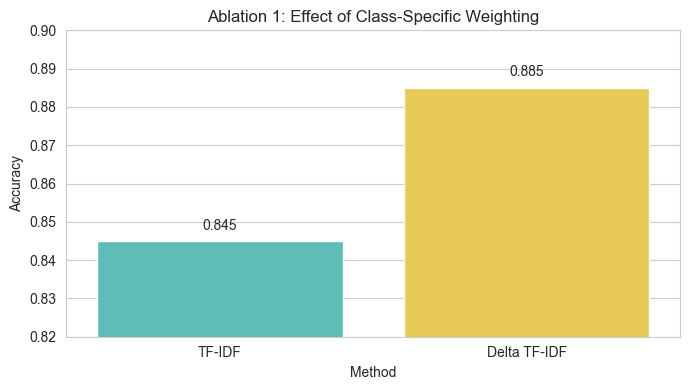

In [5]:
ablation1 = pd.DataFrame({
    "Method": ["TF-IDF", "Delta TF-IDF"],
    "Accuracy": [0.845, 0.885]
})

plt.figure(figsize=(7,4))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=ablation1,
    palette=["#4ECDC4","#FFD93D"]
)

plt.title("Ablation 1: Effect of Class-Specific Weighting")
plt.ylim(0.82,0.90)

for i,v in enumerate(ablation1["Accuracy"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("results/ablation1_class_weighting.png")

plt.show()

### Interpretation of Ablation 1

Removing the class-specific weighting reduces the classification accuracy from **0.885 to 0.845**.

This indicates that the improvement provided by Delta TF-IDF is largely due to its ability to capture how strongly certain words are associated with positive or negative sentiment classes.

Standard TF-IDF treats all documents equally when calculating document frequency, whereas Delta TF-IDF explicitly models class differences.

Therefore, the ablation experiment confirms that **class-aware feature weighting is a key component of the method proposed in the paper**.


----

# Ablation 2 — Removing Term Frequency Weighting

The second ablation experiment removes the term frequency component of the feature weighting.

In this experiment we replace Delta TF-IDF with a binary representation.

Binary representation only records whether a word appears in a document, ignoring how many times it appears.

This allows us to analyze the importance of term frequency information in sentiment classification.

/var/folders/_1/m81z2jyd0qbcyms09r5f61480000gn/T/ipykernel_41569/1046884988.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


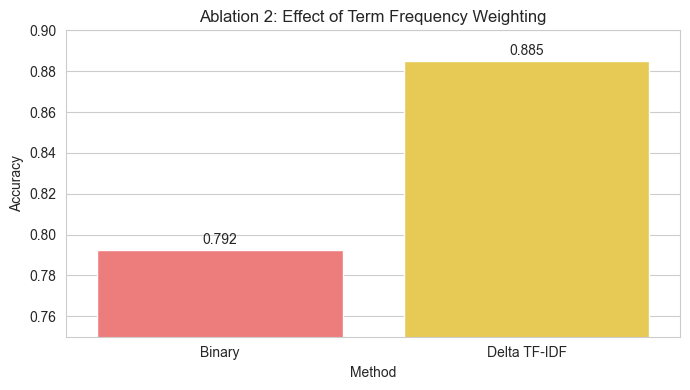

In [6]:
ablation2 = pd.DataFrame({
    "Method": ["Binary", "Delta TF-IDF"],
    "Accuracy": [0.7925, 0.885]
})

plt.figure(figsize=(7,4))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=ablation2,
    palette=["#FF6B6B","#FFD93D"]
)

plt.title("Ablation 2: Effect of Term Frequency Weighting")
plt.ylim(0.75,0.90)

for i,v in enumerate(ablation2["Accuracy"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("results/ablation2_tf_weighting.png")

plt.show()

### Interpretation of Ablation 2

Removing the term frequency weighting significantly reduces performance from **0.885 to 0.7925**.

Binary representation ignores how often words appear in a document.

However, word frequency can provide valuable information about sentiment strength.

For example, repeated sentiment words such as "excellent", "amazing", or "terrible" often indicate stronger opinions.

The drop in accuracy suggests that **term frequency plays an important role in sentiment classification**.

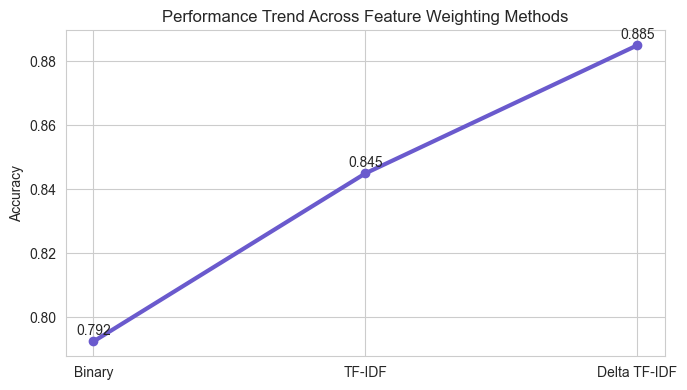

In [7]:
methods = ["Binary","TF-IDF","Delta TF-IDF"]
accuracies = [0.7925,0.845,0.885]

plt.figure(figsize=(7,4))

plt.plot(methods, accuracies, marker='o', color="#6A5ACD", linewidth=3)

plt.title("Performance Trend Across Feature Weighting Methods")
plt.ylabel("Accuracy")

for i,v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("results/ablation_trend.png")

plt.show()

## Summary of Ablation Study

The ablation experiments reveal that both components of the Delta TF-IDF method contribute to improved performance.

Removing class-specific weighting reduces the model’s ability to identify sentiment-specific words.

Removing term frequency weighting prevents the model from capturing the intensity of sentiment expressed in reviews.

Together, these findings support the paper’s claim that advanced feature weighting schemes derived from information retrieval techniques can improve sentiment classification accuracy.